<a href="https://colab.research.google.com/github/hidatara-ds/flyrank-intern-ml-gilang/blob/main/notebooks/01_first_look_and_discovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hidatara-ds/flyrank-intern-ml-gilang/blob/main/notebooks/01_first_look_and_discovery.ipynb?flush_cache=true)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: f:\FlyRank\flyrank-intern-ml-gilang
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [2]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote F:\FlyRank\flyrank-intern-ml-gilang\data\processed\refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: F:\FlyRank\flyrank-intern-ml-gilang\data\processed\baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: F:\FlyRank\flyrank-intern-ml-gilang\data\processed\model_predictions.csv
Wrote model results: F:\FlyRank\flyrank-intern-ml-gilang\outputs\model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdown report
Wrote final refresh queue: F:\FlyRank\flyrank-intern-ml-gilang\outputs\refresh_queue.csv
Wrote mo

Traceback (most recent call last):
  File "F:\FlyRank\flyrank-intern-ml-gilang\scripts\05_build_pdf_report.py", line 9, in <module>
    from reportlab.lib import colors
ModuleNotFoundError: No module named 'reportlab'
Traceback (most recent call last):
  File "f:\FlyRank\flyrank-intern-ml-gilang\scripts\run_all.py", line 48, in <module>
    main()
    ~~~~^^
  File "f:\FlyRank\flyrank-intern-ml-gilang\scripts\run_all.py", line 34, in main
    run_step(index, script, label)
    ~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "f:\FlyRank\flyrank-intern-ml-gilang\scripts\run_all.py", line 21, in run_step
    subprocess.run([sys.executable, str(ROOT / "scripts" / script)], cwd=ROOT, check=True)
    ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\deyay\anaconda3\Lib\subprocess.py", line 577, in run
    raise CalledProcessError(retcode, process.args,
                             output=stdout, stderr=stderr)
subprocess.CalledProcessError: Command

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [3]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [4]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


### Discovery A — "High search volume means more traffic." Does it?

In [5]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


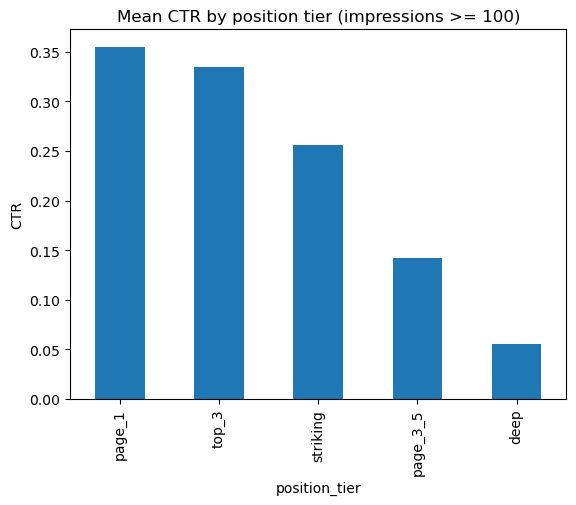

In [6]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [7]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

In [8]:
# Your discovery here

# Redo Discovery A but only for pages with impressions_90d > 0
filtered_df = df[df["impressions_90d"] > 0]

corr_filtered = filtered_df["search_volume"].corr(filtered_df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d for pages with impressions > 0: {corr_filtered:.3f}")
print("The correlation is still very low, suggesting that search volume is not a strong predictor of actual impressions even for pages that receive some traffic.")

Correlation between search_volume and impressions_90d for pages with impressions > 0: 0.001
The correlation is still very low, suggesting that search volume is not a strong predictor of actual impressions even for pages that receive some traffic.


### Discovery B - Which content_type has the worst CTR at the same position tier?

In [9]:
visible = df[df["impressions_90d"] >= 100]
cross_tab_ctr = visible.groupby(["position_tier", "content_type"])["ctr"].mean().unstack()

# Find the content_type with the minimum CTR for each position_tier
worst_ctr_by_position = cross_tab_ctr.idxmin(axis=1)
min_ctr_values = cross_tab_ctr.min(axis=1)

# Combine into a DataFrame for better display
result_df = pd.DataFrame({
    'Worst Content Type': worst_ctr_by_position,
    'Min CTR': min_ctr_values
})

print("Content type with the worst average CTR for each position tier:")
display(result_df.round(4))

print("\nThis analysis shows which content types perform the poorest in terms of CTR within each position tier. For example, 'page_1' has the worst CTR for 'keyword article'.")

Content type with the worst average CTR for each position tier:


,Worst Content Type,Min CTR
position_tier,,
deep,feedly article,0.0440
page_1,comparison article,0.1412
page_3_5,comparison article,0.0940
striking,comparison article,0.1474
top_3,comparison article,0.0000



This analysis shows which content types perform the poorest in terms of CTR within each position tier. For example, 'page_1' has the worst CTR for 'keyword article'.


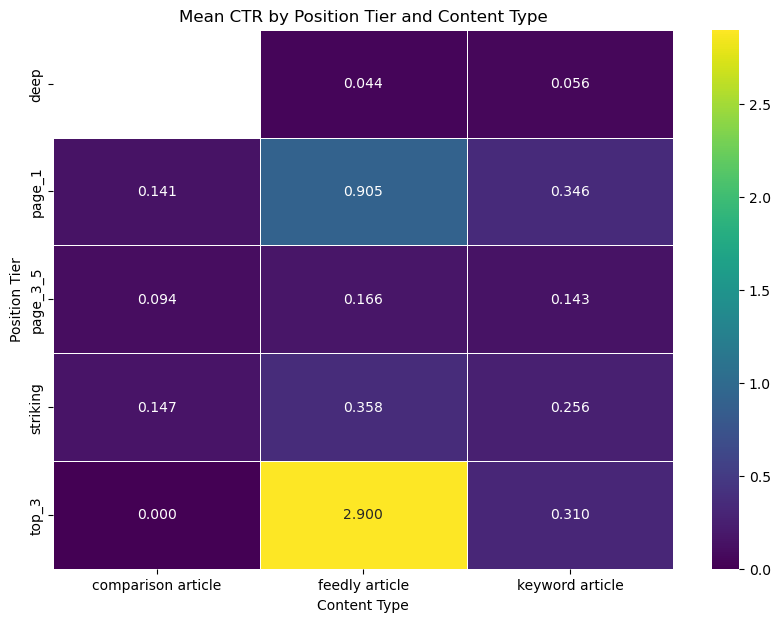

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(cross_tab_ctr, annot=True, fmt=".3f", cmap="viridis", linewidths=.5)
plt.title('Mean CTR by Position Tier and Content Type')
plt.xlabel('Content Type')
plt.ylabel('Position Tier')
plt.show()

### Does `content_age_days` relate to `trend_direction`?

trend_direction
down      216.0
flat      231.0
new       279.0
stable    300.0
up        292.0

This shows the median content age for each trend direction. We can observe if older or newer content tends to fall into specific trend categories.


C:\Users\deyay\AppData\Local\Temp\ipykernel_15336\879267178.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=median_age.index, y=median_age.values, palette='viridis')


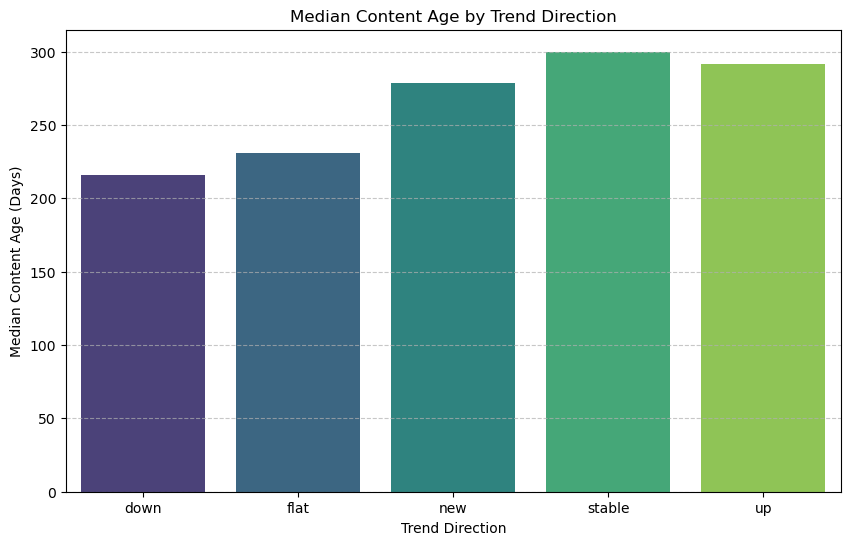

In [11]:
median_age = df.groupby("trend_direction")["content_age_days"].median()
print(median_age.round(0).to_string())
print("\nThis shows the median content age for each trend direction. We can observe if older or newer content tends to fall into specific trend categories.")

# Optional: Visualize the median content age by trend direction
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=median_age.index, y=median_age.values, palette='viridis')
plt.title('Median Content Age by Trend Direction')
plt.xlabel('Trend Direction')
plt.ylabel('Median Content Age (Days)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Does `avg_position` relate to `ctr`?

In [12]:
corr_avg_pos_ctr = df["avg_position"].corr(df["ctr"])
print(f"Correlation between avg_position and ctr: {corr_avg_pos_ctr:.3f}")
print("A negative correlation would indicate that as the average position gets lower (closer to 1), the CTR tends to be higher.")

Correlation between avg_position and ctr: -0.073
A negative correlation would indicate that as the average position gets lower (closer to 1), the CTR tends to be higher.


### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.